In [2]:
##
from spatialdata_io import xenium
import spatialdata as sd

##
from pathlib import Path
import shutil

print("parsing the data... ", end="")
sdata = xenium(
    path="Xenium_TSU-20",
    n_jobs=8,
    cell_boundaries=True,
    nucleus_boundaries=True,
    morphology_focus=True,
    cells_as_circles=True,
)
print("done")

##
print("writing the data... ", end="")
sdata.write("Xenium_TSU-20/data.zarr")
print("done")

parsing the data... 

/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_18620/995877020.py:10: DeprecationWarning: `cell_boundaries` is being deprecated as an argument to `xenium.xenium` in SpatialData version 0.1, switch to `cells_boundaries` instead.
  sdata = xenium(
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


done
INFO     The SpatialData object is not self-contained (i.e. it contains some elements that are Dask-backed from    
         locations outside Xenium_TSU-20/data.zarr). Please see the documentation of `is_self_contained()` to      
         understand the implications of working with SpatialData objects that are not self-contained.              
INFO     The Zarr backing store has been changed from None the new file path: Xenium_TSU-20/data.zarr              
done


In [1]:
%%time
import spatialdata as sd
import spatialdata_plot  # noqa: F401

sdata = sd.read_zarr(r"Xenium_TSU-20/data.zarr")
sdata

/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
version mismatch: detected: RasterFormatV02, requested: FormatV04
/Users/lyuan13/anaconda3/envs/spatial/lib/python3.11/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, f

CPU times: user 6.98 s, sys: 3.29 s, total: 10.3 s
Wall time: 27.7 s


SpatialData object, with associated Zarr store: /Users/lyuan13/Downloads/Xenium_TSU-20/data.zarr
├── Images
│     ├── 'morphology_focus': DataTree[cyx] (1, 20500, 17134), (1, 10250, 8567), (1, 5125, 4283), (1, 2562, 2141), (1, 1281, 1070)
│     └── 'morphology_mip': DataTree[cyx] (1, 20500, 17134), (1, 10250, 8567), (1, 5125, 4283), (1, 2562, 2141), (1, 1281, 1070)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (20500, 17134), (10250, 8567), (5125, 4283), (2562, 2141), (1281, 1070)
│     └── 'nucleus_labels': DataTree[yx] (20500, 17134), (10250, 8567), (5125, 4283), (2562, 2141), (1281, 1070)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (58648, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (58648, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (58648, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (58648, 302)
with coordinate systems:
    ▸ 'gl

Largest cell radius: 18.695198179498757
99th percentile of radius: 11.205131339653459


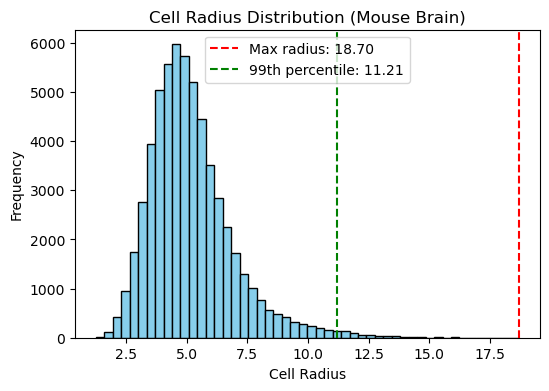

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Extract radii
cells_gdf = sdata.shapes['cell_circles']
radii = cells_gdf['radius']

# Compute stats
max_radius = radii.max()
percentile_99 = np.percentile(radii, 99)

print(f"Largest cell radius: {max_radius}")
print(f"99th percentile of radius: {percentile_99}")

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(radii, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Cell Radius')
plt.ylabel('Frequency')
plt.title('Cell Radius Distribution (Mouse Brain)')

# Annotate max and 99th percentile
plt.axvline(max_radius, color='red', linestyle='--', label=f'Max radius: {max_radius:.2f}')
plt.axvline(percentile_99, color='green', linestyle='--', label=f'99th percentile: {percentile_99:.2f}')

# Add legend
plt.legend()

# Save figure as PNG
plt.savefig('lung_cancer_cell_radius_distribution.png', dpi=300)
plt.show()

In [2]:
transcripts = sdata.points["transcripts"].compute()
transcripts.shape

(1643068, 10)

In [3]:
# Filter by qv > 30
filtered_df = transcripts[transcripts["qv"] > 30]

# Filter by feature_name
genes = sdata.tables["table"].var.index
filtered_df = filtered_df[filtered_df["feature_name"].isin(genes)]
filtered_df.shape

(1436900, 10)

In [9]:
filtered_df.head()

,x,y,z,feature_name,cell_id,codeword_index,transcript_id,overlaps_nucleus,nucleus_distance,qv,fov_name
1,202.231186,1421.553955,16.527092,THBS2,UNASSIGNED,46,281582350895222,0,327.802612,40.000000,C2
2,60.755959,1427.187744,16.859751,CXCR4,UNASSIGNED,379,281582350896236,0,359.865814,38.001629,C2
3,116.347923,1415.833618,16.661528,CXCR4,UNASSIGNED,379,281582350896244,0,349.481201,40.000000,C2
4,195.983978,1445.074829,16.494038,EGFL7,UNASSIGNED,223,281582350896355,0,304.836700,40.000000,C2
5,64.536530,1440.388916,16.667513,PROX1,UNASSIGNED,233,281582350897810,0,346.369476,40.000000,C2


In [10]:
filtered_df.to_parquet("lung_cancer_filtered_df.parquet", engine="pyarrow", index=False)

In [17]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# Starting nucleus df
nuc_df = filtered_df[
    (filtered_df["cell_id"] != "UNASSIGNED") &
    (filtered_df["overlaps_nucleus"] == 1)
].copy()

# Count transcripts per nucleus
nuc_counts = nuc_df.groupby("cell_id").size()

# Compute thresholds
low_thres = np.percentile(nuc_counts, 20)
high_thres = np.percentile(nuc_counts, 80)

print("Transcript count thresholds:", low_thres, high_thres)

# Keep only "confident" nuclei
good_nuc_ids = nuc_counts[(nuc_counts >= low_thres) & (nuc_counts <= high_thres)].index
nuc_df_confident = nuc_df[nuc_df["cell_id"].isin(good_nuc_ids)].copy()

print("Number of confident nuclei:", len(good_nuc_ids))

Transcript count thresholds: 3.0 22.0
Number of confident nuclei: 38021


In [18]:
def compute_npmi_presence_absence(
    df_subset,
    group_key="cell_id",
    min_occurrences_per_context=2
):
    """
    Compute PMI/NPMI using presence/absence of genes at the cell or nucleus level,
    with robustness control by requiring each gene to occur at least N times
    within a context (cell or nucleus) before being considered "present".

    Returns
    -------
    long_df : DataFrame
        Columns:
            gene_i, gene_j, P_i, P_j, P_ij,
            P_i_given_j, P_j_given_i, PMI, NPMI
    """

    # 0. Subset to necessary columns
    df = df_subset[[group_key, "feature_name"]].copy()

    # ----------------------------------------------------------------------
    # Filter by minimum occurrences per context
    # ----------------------------------------------------------------------
    # Count gene occurrences within each cell/nucleus
    counts = (
        df.groupby([group_key, "feature_name"])
        .size()
        .rename("gene_count")
        .reset_index()
    )

    # Keep only those gene occurrences with enough counts
    df_filtered = counts[counts["gene_count"] >= min_occurrences_per_context].copy()

    if df_filtered.empty:
        raise ValueError(
            f"No genes pass min_occurrences_per_context={min_occurrences_per_context}."
        )

    # For presence/absence, set value = 1 for all retained (context, gene) pairs
    df_filtered["value"] = 1

    # ----------------------------------------------------------------------
    # Pivot to contexts × genes matrix (presence/absence)
    # ----------------------------------------------------------------------
    M = df_filtered.pivot_table(
        index=group_key,
        columns="feature_name",
        values="value",
        aggfunc="max",
        fill_value=0
    )

    contexts = M.index.to_numpy()
    genes = M.columns.to_numpy()
    C = M.shape[0]

    # ----------------------------------------------------------------------
    # Probabilities P(i), P(i,j)
    # ----------------------------------------------------------------------
    counts_i = M.sum(axis=0).to_numpy()
    P_i = counts_i / C

    co_matrix = (M.T @ M).to_numpy()
    P_ij = co_matrix / C

    # ----------------------------------------------------------------------
    # Conditional probabilities
    # ----------------------------------------------------------------------
    P_i_col = P_i[:, None]
    P_j_row = P_i[None, :]

    with np.errstate(divide="ignore", invalid="ignore"):
        P_i_given_j = np.where(P_j_row > 0, P_ij / P_j_row, np.nan)
        P_j_given_i = np.where(P_i_col > 0, P_ij / P_i_col, np.nan)

    # ----------------------------------------------------------------------
    # PMI & NPMI
    # ----------------------------------------------------------------------
    PMI = np.full_like(P_ij, np.nan)
    NPMI = np.full_like(P_ij, np.nan)

    denom = P_i_col * P_j_row
    valid = (P_ij > 0) & (denom > 0)

    with np.errstate(divide="ignore", invalid="ignore"):
        PMI[valid] = np.log(P_ij[valid] / denom[valid])
        NPMI[valid] = PMI[valid] / (-np.log(P_ij[valid]))

    # ----------------------------------------------------------------------
    # Convert to long format
    # ----------------------------------------------------------------------
    G = len(genes)
    long_df = pd.DataFrame({
        "gene_i": np.repeat(genes, G),
        "gene_j": np.tile(genes, G),
        "P_i": np.repeat(P_i, G),
        "P_j": np.tile(P_i, G),
        "P_ij": P_ij.ravel(),
        "P_i_given_j": P_i_given_j.ravel(),
        "P_j_given_i": P_j_given_i.ravel(),
        "PMI": PMI.ravel(),
        "NPMI": NPMI.ravel(),
    })

    return long_df

In [19]:
nucleus_npmi_long = compute_npmi_presence_absence(nuc_df_confident, group_key="cell_id", min_occurrences_per_context=2)

/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_71477/1993952283.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby([group_key, "feature_name"])
/var/folders/_2/50fjjk3d1696gqy3jz2ypb9j88m1t6/T/ipykernel_71477/1993952283.py:47: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  M = df_filtered.pivot_table(


In [20]:
print("PMI: min =", np.nanmin(nucleus_npmi_long.PMI), "max =", np.nanmax(nucleus_npmi_long.PMI))
print("NPMI: min =", np.nanmin(nucleus_npmi_long.NPMI), "max =", np.nanmax(nucleus_npmi_long.NPMI))

PMI: min = -3.4973836810597243 max = 10.268095943298984
NPMI: min = -0.4003231001210188 max = 1.0000000000000002


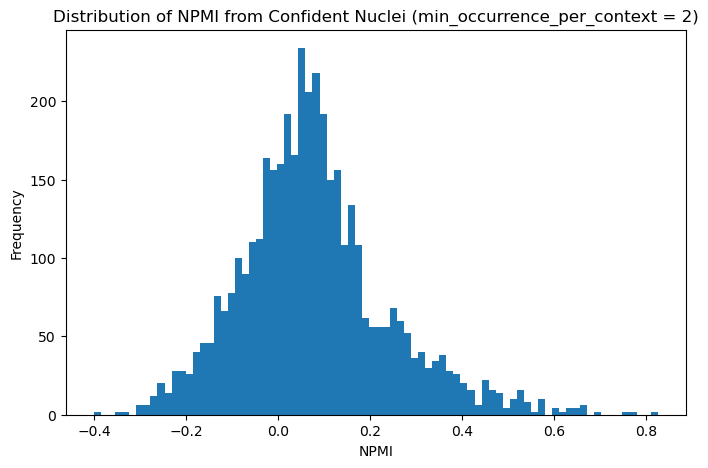

Top 10 highest NPMI gene pairs:
        gene_i  gene_j       P_i       P_j      P_ij  P_i_given_j  P_j_given_i  \
8905   CLEC4C    GZMB  0.000035  0.000208  0.000035     0.166667     1.000000   
17892    GZMB  CLEC4C  0.000208  0.000035  0.000035     1.000000     0.166667   
5291     CD19  CLEC2D  0.000035  0.000347  0.000035     0.100000     1.000000   
8635   CLEC2D    CD19  0.000347  0.000035  0.000035     1.000000     0.100000   
40739     TNF    ZEB1  0.000069  0.000208  0.000035     0.166667     0.500000   
44083    ZEB1     TNF  0.000208  0.000069  0.000035     0.500000     0.166667   
9773    CSPG4   LAMC3  0.000174  0.000486  0.000069     0.142857     0.400000   
23776   LAMC3   CSPG4  0.000486  0.000174  0.000069     0.400000     0.142857   
9760    CSPG4   ITGAM  0.000174  0.000208  0.000035     0.166667     0.200000   
21046   ITGAM   CSPG4  0.000208  0.000174  0.000035     0.200000     0.166667   

            PMI      NPMI  
8905   8.476336  0.825502  
17892  8.476336  0.

In [15]:
# exclude self-pairs
nucleus_npmi_pairs = nucleus_npmi_long[
    nucleus_npmi_long["gene_i"] != nucleus_npmi_long["gene_j"]
].copy()

plt.figure(figsize=(8,5))
plt.hist(nucleus_npmi_pairs["NPMI"].dropna(), bins=80)
plt.xlabel("NPMI")
plt.ylabel("Frequency")
plt.title("Distribution of NPMI from Confident Nuclei (min_occurrence_per_context = 2)")
plt.show()

# Top 10 positive
top10 = nucleus_npmi_pairs.nlargest(10, "NPMI")
print("Top 10 highest NPMI gene pairs:\n", top10)

# Bottom 10
bottom10 = nucleus_npmi_pairs.nsmallest(10, "NPMI")
print("Bottom 10 lowest NPMI gene pairs:\n", bottom10)

In [17]:
nucleus_npmi_long.to_csv("lung_cancer_nucleus_npmi_long_min_count_2.csv", index=False)